In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

In [36]:
ee.Authenticate()
ee.Initialize()

In [2]:
YEARS = list(range(2000, 2023))
CSV_DIR = './spatial_clusters'  
FILE_PATTERN = 'spatial_{year}.csv'
ID_COL = 's2_id'
CLUSTER_COL = 'cluster'
STABILITY_THRESHOLD = 70.0 
CLUSTER_COL = 'cluster'
FRAC_COLS = [
    'crop_frac', 'tree_frac', 'shrub_frac', 'bare_frac', 
    'water_frac', 'built_frac', 'wetland_frac', 'snow_frac'
]

CLASS_LABELS = {c: c.replace('_frac', '').capitalize() for c in FRAC_COLS}

In [5]:
def load_spatial_data():
    """
    Loads CSV files for each year and merges them into a single wide DataFrame.
    Rows: s2_id, Columns: Years, Values: Cluster ID
    """
    dfs = []
    for year in YEARS:
        # Construct the file path
        path = os.path.join(CSV_DIR, FILE_PATTERN.format(year=year))
        
        if not os.path.exists(path):
            print(f"[MISSING] {path}")
            continue
            
        print(f"Loading {year}...")
        # Read the CSV, ensuring IDs are strings to avoid precision issues
        df = pd.read_csv(path, dtype={ID_COL: str})
        
        # Keep only the ID and the cluster assignment
        df = df[[ID_COL, CLUSTER_COL]]
        
        # Ensure cluster is an integer, use -1 for missing values
        df[CLUSTER_COL] = pd.to_numeric(df[CLUSTER_COL], errors='coerce').fillna(-1).astype(int)
        
        # Rename column to the year for the wide format
        df = df.rename(columns={CLUSTER_COL: str(year)})
        dfs.append(df.set_index(ID_COL))
    
    # Merge all years into one large dataframe
    full_df = pd.concat(dfs, axis=1)
    return full_df

def compute_stability_metrics(df):
    """
    Computes stability metrics for each spatial ID.
    """
    results = []
    print("Computing stability metrics...")
    
    for s2_id, row in df.iterrows():
        # Filter out missing data (-1)
        valid = row[row != -1]
        
        if len(valid) == 0:
            results.append({
                ID_COL: s2_id,
                'mode_cluster': -1,
                'mode_freq': 0,
                'stability_pct': 0.0,
                'n_unique': 0,
                'is_stable': False,
                'valid_years': 0
            })
            continue
            
        counts = Counter(valid)
        mode_cls, mode_freq = counts.most_common(1)[0]
        stab_pct = round(mode_freq / len(valid) * 100, 1)
        
        results.append({
            ID_COL: s2_id,
            'mode_cluster': mode_cls,
            'mode_freq': mode_freq,
            'stability_pct': stab_pct,
            'n_unique': len(counts),
            'is_stable': stab_pct >= STABILITY_THRESHOLD,
            'valid_years': len(valid)
        })
        
    return pd.DataFrame(results).set_index(ID_COL)

def plot_stability_results(stability_df):
    """
    Generates a histogram of stability percentages.
    """
    plt.figure(figsize=(10, 6))
    s = stability_df['stability_pct']
    plt.hist(s[s > 0], bins=20, color='teal', edgecolor='white')
    plt.axvline(STABILITY_THRESHOLD, color='red', linestyle='--', 
                label=f'{STABILITY_THRESHOLD}% threshold')
    
    plt.title('Spatial Cluster Stability Distribution (2000-2022)')
    plt.xlabel('% years assigned to the most frequent (modal) cluster')
    plt.ylabel('Number of grids')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.savefig('spatial_stability_histogram.png', dpi=150)
    plt.show()

def plot_transitions(wide_df):
    """
    Calculates and plots the percentage of grids that change cluster year-over-year.
    """
    year_cols = [str(y) for y in YEARS if str(y) in wide_df.columns]
    change_rates = []
    
    for i in range(len(year_cols) - 1):
        y1, y2 = year_cols[i], year_cols[i+1]
        # Only compare grids present in both years and not -1
        both = wide_df[[y1, y2]].replace(-1, np.nan).dropna()
        if len(both) == 0: continue
        
        changed = (both[y1] != both[y2]).sum()
        total = len(both)
        change_rates.append({
            'transition': f'{y1}→{y2}',
            'pct_changed': round(changed / total * 100, 1)
        })
    
    tr_df = pd.DataFrame(change_rates)
    
    plt.figure(figsize=(15, 5))
    plt.bar(tr_df['transition'], tr_df['pct_changed'], color='salmon', edgecolor='white')
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.ylabel('% grids that changed cluster')
    plt.title('Year-over-Year Spatial Cluster Transitions')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('spatial_transitions.png', dpi=150)
    plt.show()

In [6]:
# 1. Load data
wide_data = load_spatial_data()

Loading 2000...
Loading 2001...
Loading 2002...
Loading 2003...
Loading 2004...
Loading 2005...
Loading 2006...
Loading 2007...
Loading 2008...
Loading 2009...
Loading 2010...
Loading 2011...
Loading 2012...
Loading 2013...
Loading 2014...
Loading 2015...
Loading 2016...
Loading 2017...
Loading 2018...
Loading 2019...
Loading 2020...
Loading 2021...
Loading 2022...


In [7]:
# 2. Run analysis
stability_results = compute_stability_metrics(wide_data)

Computing stability metrics...


In [8]:
# 3. Print Summary
print(f"Stable grids (>= {STABILITY_THRESHOLD}%): {stability_results['is_stable'].sum()} / {len(stability_results)}")
print(f"Average Stability: {stability_results['stability_pct'].mean():.2f}%")

Stable grids (>= 70.0%): 2177510 / 2256839
Average Stability: 97.92%


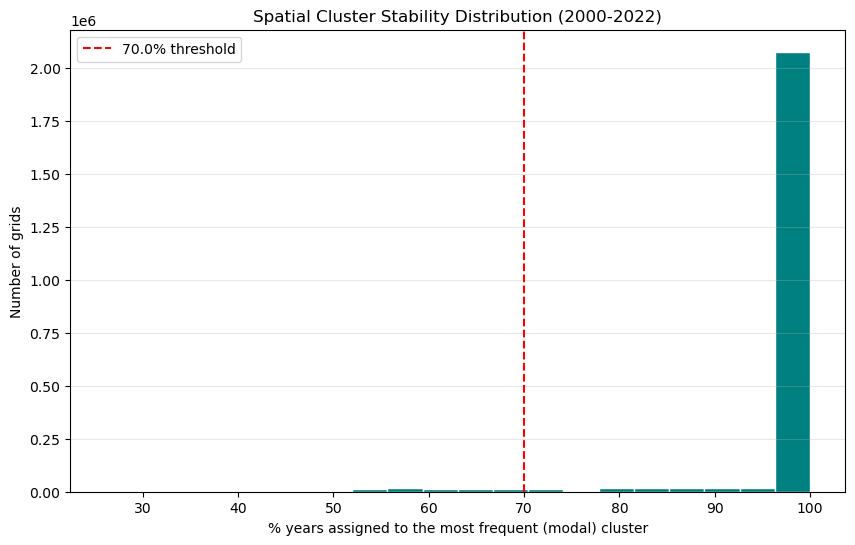

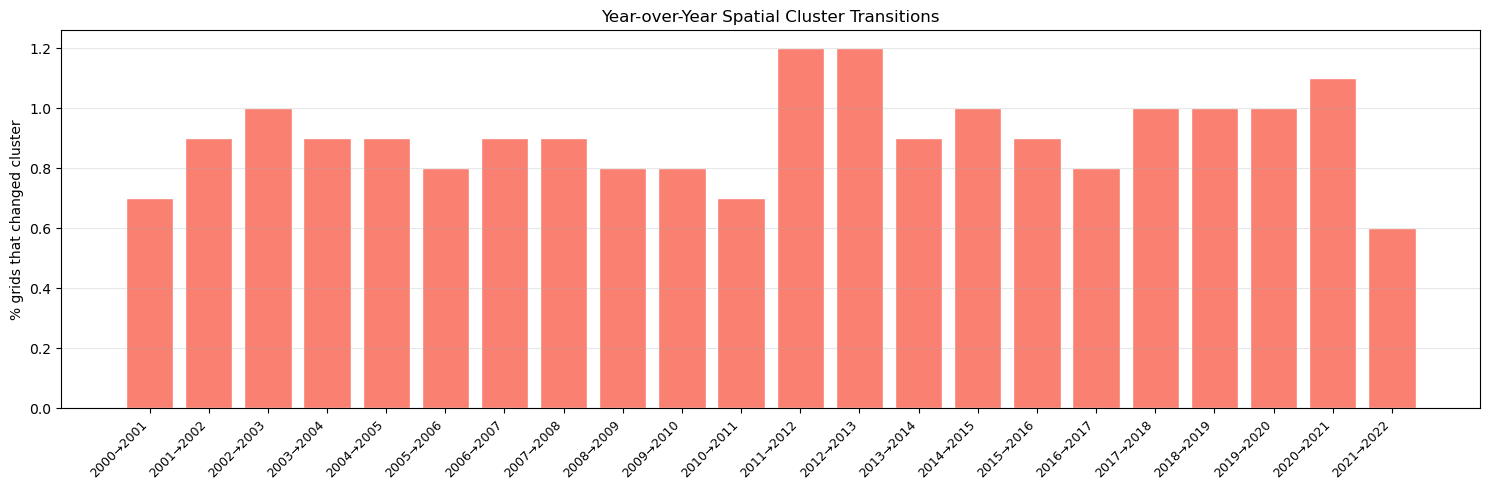

In [9]:
# 4. Visualize
plot_stability_results(stability_results)
plot_transitions(wide_data)

In [13]:
def plot_transitions_per_cluster_percentage(wide_df, n_clusters=8):
    """
    Plots the percentage of grids that changed out of each cluster in separate subplots
    using descriptive cluster names instead of numerical IDs.
    """
    # Mapping dictionary based on your cluster descriptions
    cluster_names = {
        0: "Mostly trees",
        1: "Intensive croplands",
        2: "Himalayan areas",
        3: "Mostly wetlands",
        4: "Bare and shrub areas",
        5: "Mostly shrublands",
        6: "Agricultural-residential areas",
        7: "Riverine and coastal areas"
    }

    year_cols = [str(y) for y in YEARS if str(y) in wide_df.columns]
    transition_data = {}
    labels = []

    for i in range(len(year_cols) - 1):
        y1, y2 = year_cols[i], year_cols[i+1]
        label = f'{y1}→{y2}'
        labels.append(label)
        
        both = wide_df[[y1, y2]].replace(-1, np.nan).dropna()
        cluster_percentages = []
        
        for c in range(n_clusters):
            # Grids that started in cluster c during year y1
            starts_in_c = both[both[y1] == c]
            total_in_cluster = len(starts_in_c)
            
            if total_in_cluster > 0:
                # Number of grids that changed to a different cluster in y2
                num_changed = (starts_in_c[y1] != starts_in_c[y2]).sum()
                # Calculate percentage
                pct_changed = (num_changed / total_in_cluster) * 100
            else:
                pct_changed = 0.0
                
            cluster_percentages.append(pct_changed)
        
        transition_data[label] = cluster_percentages

    # Use descriptive column identifiers for the data frame to keep tracks clean
    plot_df = pd.DataFrame(transition_data, index=[f'Cluster {i}' for i in range(n_clusters)]).T

    # Setup subplots: 4 rows, 2 columns for 8 clusters
    fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 20), sharex=True)
    axes = axes.flatten()
    colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

    for i in range(n_clusters):
        cluster_id_label = f'Cluster {i}'
        # Fallback to generic name if index out of dictionary range
        descriptive_name = cluster_names.get(i, f"Cluster {i}") 
        ax = axes[i]
        
        ax.bar(plot_df.index, plot_df[cluster_id_label], color=colors[i], edgecolor='black', alpha=0.8)
        
        # Updated to display the descriptive name in the subplot titles
        ax.set_title(f'Transitions Out of {descriptive_name} (%)', fontsize=13, fontweight='bold')
        ax.set_ylabel('% of Grids Changed')
        ax.grid(axis='y', linestyle='--', alpha=0.6)
        
        # Ensure the y-axis represents percentages neatly up to 100% if needed
        ax.set_ylim(0, max(plot_df[cluster_id_label].max() * 1.1, 10)) 
        
        # Rotate x-labels only for the bottom plots
        if i >= 6:
            ax.set_xticklabels(plot_df.index, rotation=45, ha='right')

    plt.suptitle('Yearly Transition Percentage per Source Cluster (Stability Metric)', fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

C:\Users\navan\AppData\Local\Temp\ipykernel_14760\2931965916.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df.index, rotation=45, ha='right')
C:\Users\navan\AppData\Local\Temp\ipykernel_14760\2931965916.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df.index, rotation=45, ha='right')


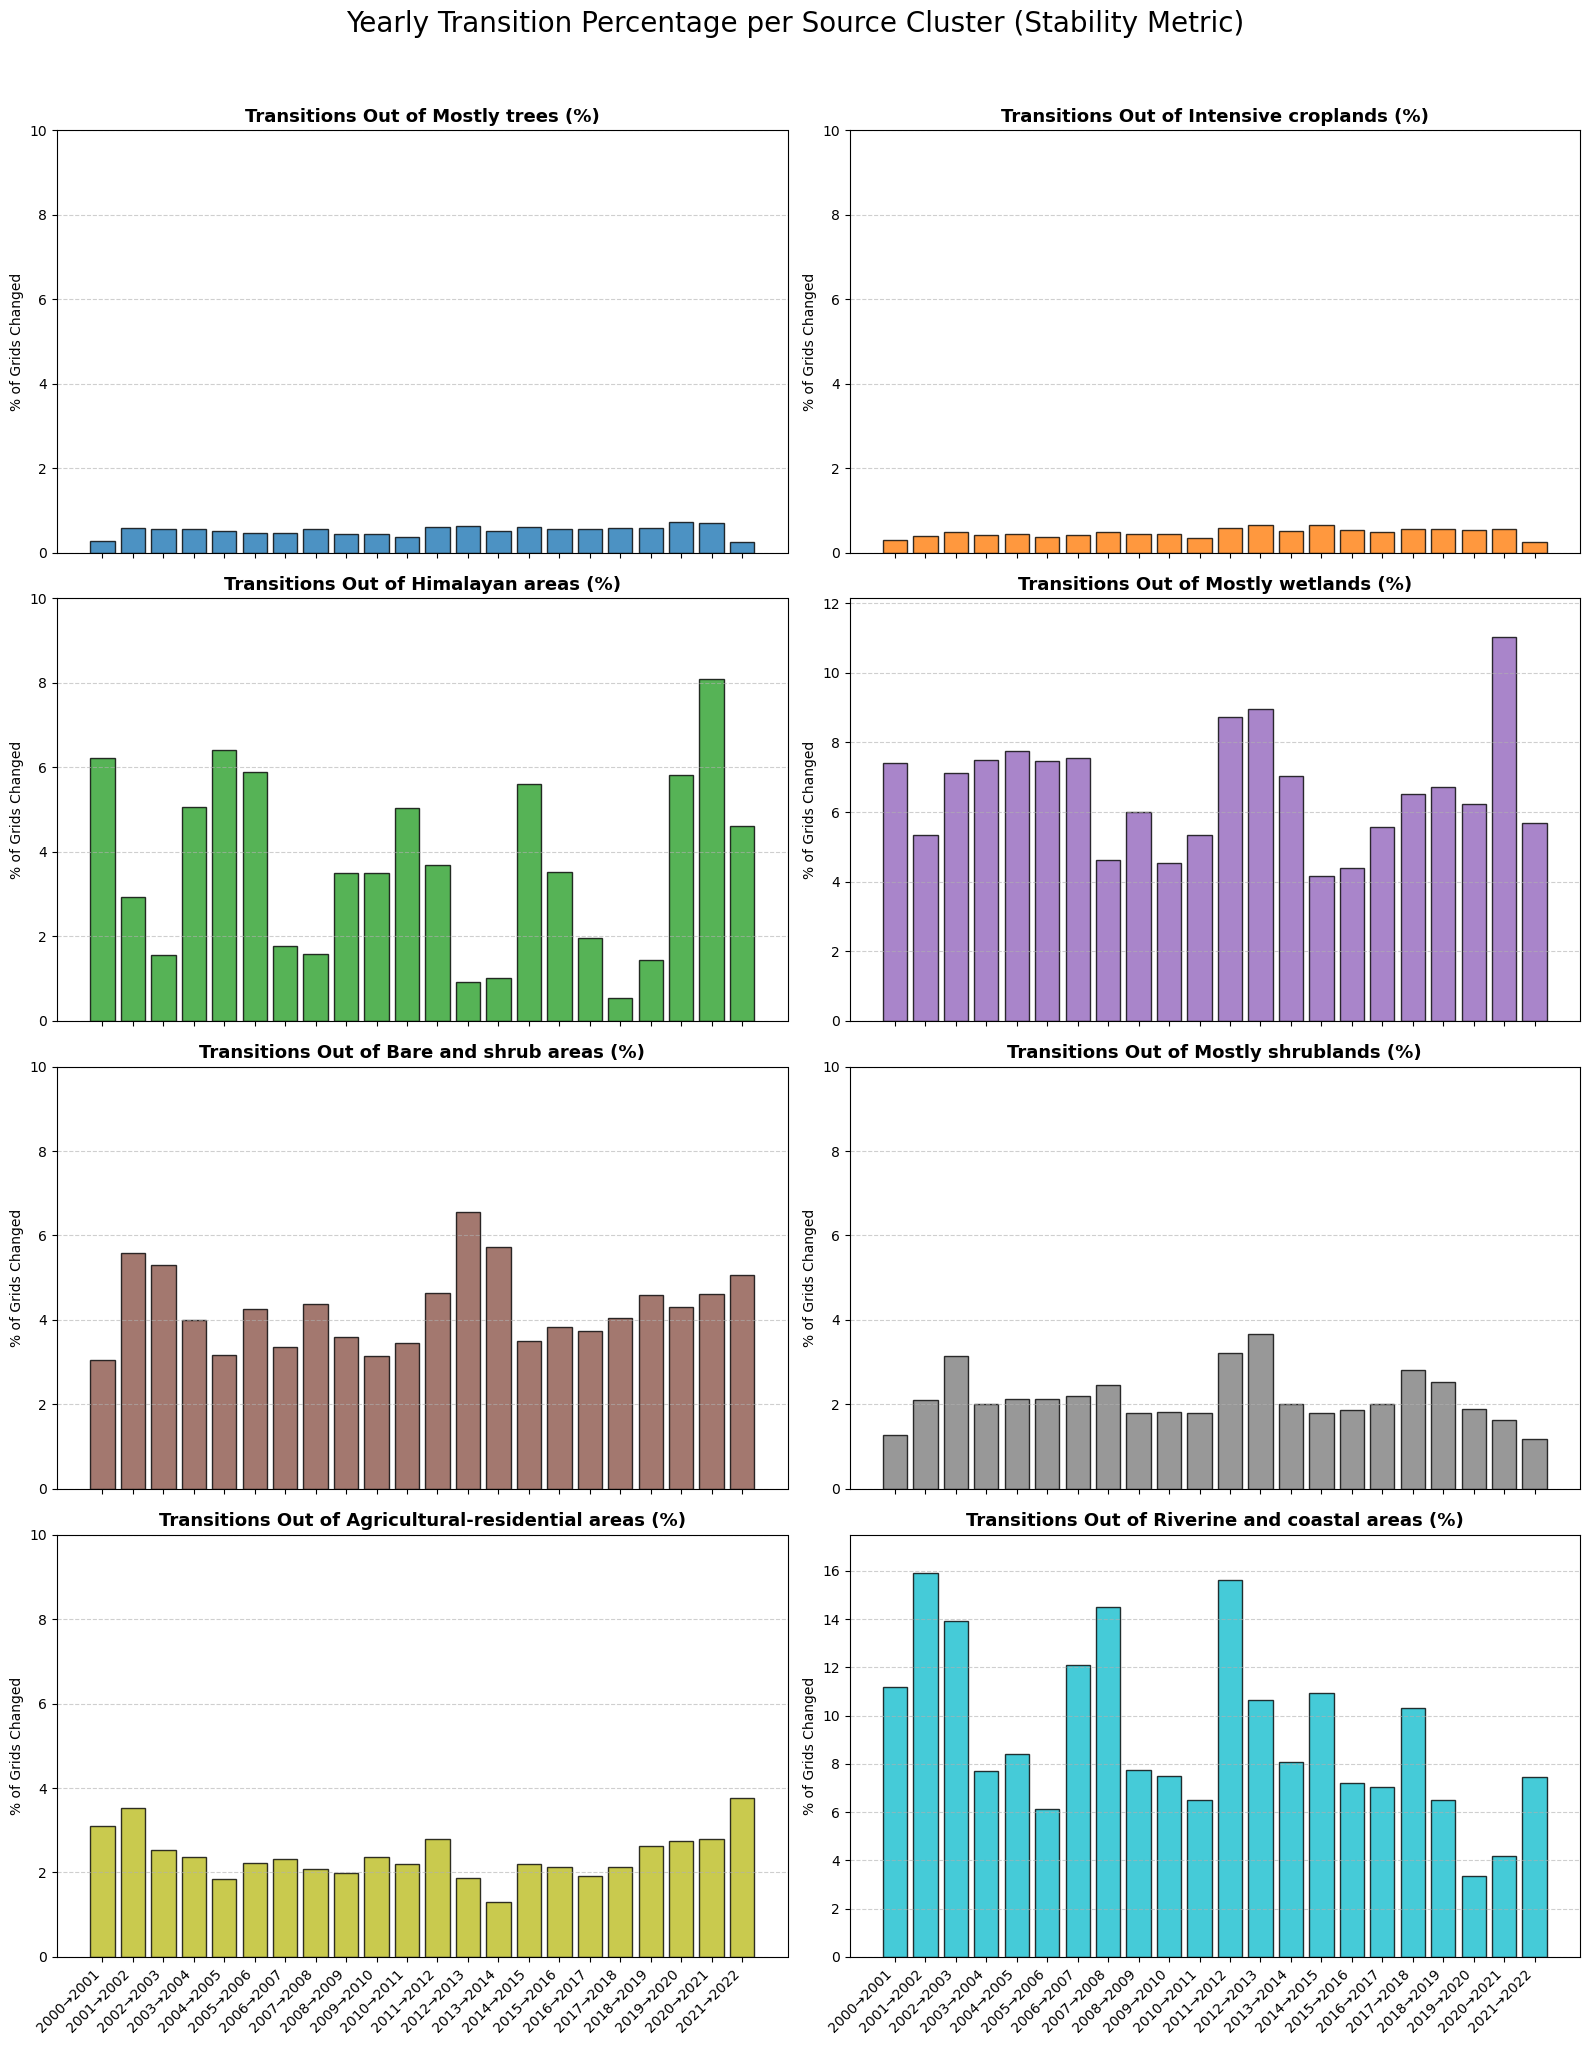

In [14]:
plot_transitions_per_cluster_percentage(wide_data, n_clusters=8)

In [53]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_transitions_per_cluster_percentage(wide_df, n_clusters=8):
    """Plots a stacked bar chart for each cluster (1 per row).

    Transitions to other clusters are placed at the bottom baseline, with the
    'Stayed Same' stable percentage stacked on top.
    """
    cluster_names = {
        0: "Mostly trees",
        1: "Intensive croplands",
        2: "Himalayan areas",
        3: "Mostly wetlands",
        4: "Bare and shrub areas",
        5: "Mostly shrublands",
        6: "Agricultural-residential areas",
        7: "Riverine and coastal areas"
    }

    # Custom explicit color map matching your structural categories
    cluster_colors = {
        0: "#2ca02c",  # Green (Mostly trees)
        1: "#FFD700",  # Gold (Intensive croplands)
        2: "#8B4513",  # SaddleBrown (Himalayan areas)
        3: "#1E90FF",  # DodgerBlue (Mostly wetlands)
        4: "#9467bd",  # Purple (Bare and shrub areas)
        5: "#ff7f0e",  # Orange (Mostly shrublands)
        6: "#e377c2",  # Pink (Agricultural-residential areas)
        7: "#20B2AA"   # LightSeaGreen (Riverine and coastal areas)
    }

    year_cols = [str(y) for y in YEARS if str(y) in wide_df.columns]
    labels = []

    for i in range(len(year_cols) - 1):
        labels.append(f"{year_cols[i]}→{year_cols[i+1]}")

    columns_with_stayed = list(range(n_clusters)) + ["Stayed Same"]
    source_dfs = {
        src: pd.DataFrame(0.0, index=labels, columns=columns_with_stayed)
        for src in range(n_clusters)
    }

    # Populate transition metrics
    for i in range(len(year_cols) - 1):
        y1, y2 = year_cols[i], year_cols[i + 1]
        label = f"{y1}→{y2}"

        both = wide_df[[y1, y2]].replace(-1, np.nan).dropna()

        for src in range(n_clusters):
            starts_in_src = both[both[y1] == src]
            total_in_cluster = len(starts_in_src)

            if total_in_cluster > 0:
                # 1. Calculate how many stayed completely stable
                num_stayed = (starts_in_src[y1] == starts_in_src[y2]).sum()
                source_dfs[src].at[label, "Stayed Same"] = (
                    num_stayed / total_in_cluster
                ) * 100

                # 2. Calculate destination breakdown for the ones that changed
                changed_grids = starts_in_src[
                    starts_in_src[y1] != starts_in_src[y2]
                ]
                if len(changed_grids) > 0:
                    counts = changed_grids[y2].value_counts()
                    for dest in range(n_clusters):
                        if dest in counts.index:
                            pct = (counts[dest] / total_in_cluster) * 100
                            source_dfs[src].at[label, dest] = pct

    # Setup subplots: 1 column per plot, 8 rows total
    fig, axes = plt.subplots(
        nrows=n_clusters,
        ncols=1,
        figsize=(15, 6 * n_clusters),
        sharex=True,
    )

    for src in range(n_clusters):
        ax = axes[src]
        df = source_dfs[src]
        descriptive_name = cluster_names.get(src, f"Cluster {src}")

        # We start building the stack from the absolute bottom baseline (0%)
        bottom_bars = np.zeros(len(df))

        # 1. Plot the transition changes FIRST (at the bottom)
        for dest in range(n_clusters):
            if src == dest:
                continue  # Skip self-transition

            ax.bar(
                df.index,
                df[dest],
                bottom=bottom_bars,
                label=cluster_names.get(dest, f"Cluster {dest}"),
                color=cluster_colors[dest],
                edgecolor="black",
                linewidth=0.5,
                alpha=0.85,
            )
            bottom_bars += df[dest]

        # 2. Stack the "Stayed Same" layer LAST (pushes it to the top)
        ax.bar(
            df.index,
            df["Stayed Same"],
            bottom=bottom_bars,
            label="Stayed the Same (Stable)",
            color="#E0E0E0",
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
        )

        # Formatting Each Subplot
        ax.set_title(
            f"Transition Destination Breakdown: {descriptive_name}",
            fontsize=14,
            fontweight="bold",
            pad=10,
        )
        ax.set_ylabel("% of Total Cluster Grids", fontsize=11)
        ax.set_ylim(0, 100)
        # 🔥 FIXED TYPO HERE:
        ax.grid(axis="y", linestyle="--", alpha=0.5)

    # Rotate final x-axis labels
    axes[-1].set_xticklabels(labels, rotation=45, ha="right", fontsize=11)

    # Explicitly create comprehensive legend handles
    legend_handles = []

    # Add the 8 destination cluster colors with borders
    for cl_id in range(n_clusters):
        patch = mpatches.Patch(
            color=cluster_colors[cl_id],
            label=cluster_names[cl_id],
            linewidth=0.5,
            linestyle="-",
        )
        legend_handles.append(patch)

    # Append the "Stayed the Same" stable gray box at the end
    legend_handles.append(
        mpatches.Patch(
            color="#E0E0E0", label="Stayed the Same (Stable)", linewidth=0.5
        )
    )

    # Render unified global legend layout using fixed handles
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.99),
        ncol=5,
        fontsize=11,
        title="Legend / Destination Clusters",
        title_fontsize=13,
    )

    plt.suptitle(
        "Yearly Grid Activity Breakdown Per Source Cluster (Includes Stability & Transitions)",
        fontsize=22,
        y=1.01,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.subplots_adjust(top=0.96)
    plt.show()

C:\Users\navan\AppData\Local\Temp\ipykernel_14760\4134208372.py:134: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[-1].set_xticklabels(labels, rotation=45, ha="right", fontsize=11)


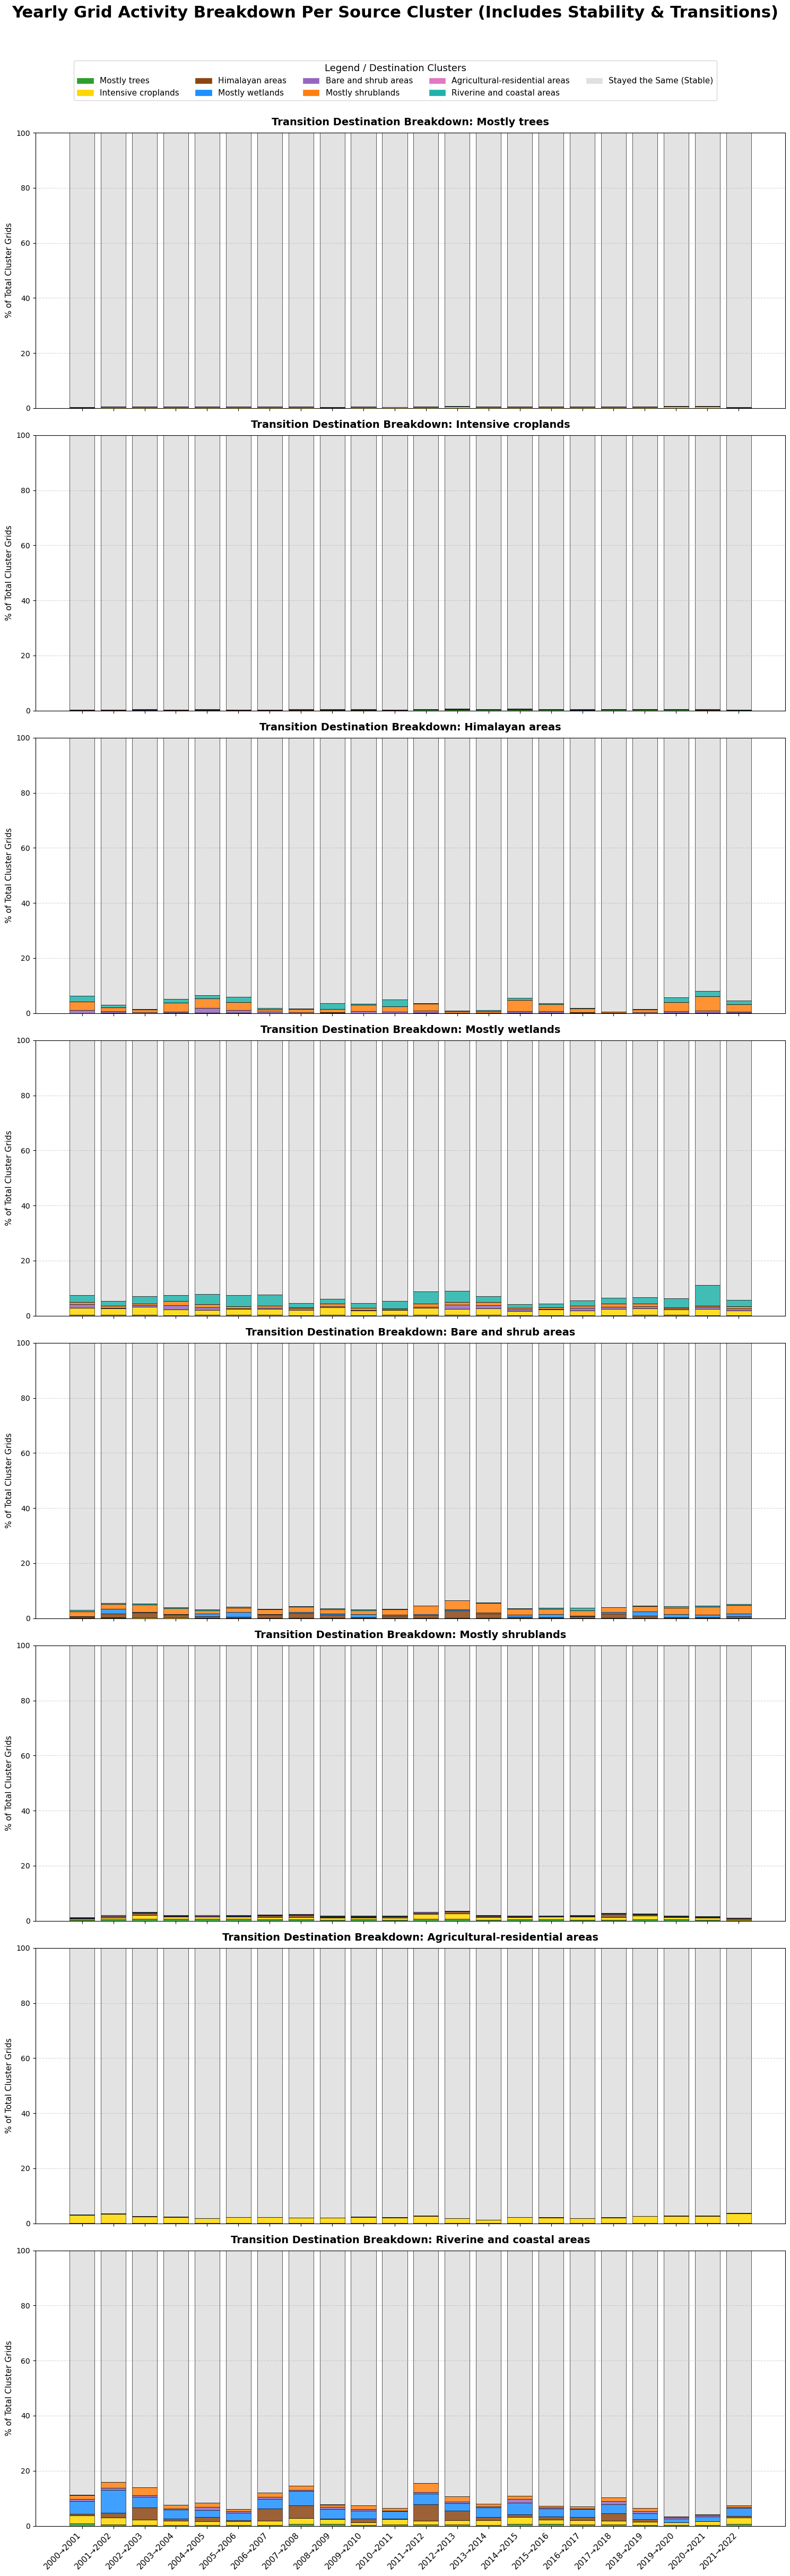

In [16]:
plot_transitions_per_cluster_percentage(wide_data, n_clusters=8)

## Finding problematic grids

In [33]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pandas as pd
import seaborn as sns


def plot_transition_timeline(
    df, start_year, end_year, source_cluster, target_cluster
):
    """Filters a wide dataframe for grids matching a specific year-over-year transition,

    ranks them internally by overall lifecycle volatility, and plots a
    categorical heatmap.
    """
    cluster_names = {
        0: "Mostly trees",
        1: "Intensive croplands",
        2: "Himalayan areas",
        3: "Mostly wetlands",
        4: "Bare and shrub areas",
        5: "Mostly shrublands",
        6: "Agricultural-residential areas",
        7: "Riverine and coastal areas"
    }

    cluster_colors = {
        0: "#2ca02c",  # Green (Mostly trees)
        1: "#FFD700",  # Gold (Intensive croplands)
        2: "#8B4513",  # SaddleBrown (Himalayan areas)
        3: "#1E90FF",  # DodgerBlue (Mostly wetlands)
        4: "#9467bd",  # Purple (Bare and shrub areas)
        5: "#ff7f0e",  # Orange (Mostly shrublands)
        6: "#e377c2",  # Pink (Agricultural-residential areas)
        7: "#20B2AA"   # LightSeaGreen (Riverine and coastal areas)
    }
    
    categorical_cmap = ListedColormap(list(cluster_colors.values()))

    all_years = [str(yr) for yr in range(2000, 2023)]
    available_years = [yr for yr in all_years if yr in df.columns]

    start_year = str(start_year)
    end_year = str(end_year)

    if start_year not in df.columns or end_year not in df.columns:
        print(
            f"Error: Transition years {start_year} or {end_year} not found in DataFrame columns."
        )
        return

    matched_condition = (df[start_year] == source_cluster) & (
        df[end_year] == target_cluster
    )
    filtered_df = df[matched_condition]

    if filtered_df.empty:
        print(
            f"No grids found matching the transition: {source_cluster} → {target_cluster} between {start_year} and {end_year}."
        )
        return

    yoy_changes = filtered_df[available_years].ne(
        filtered_df[available_years].shift(-1, axis=1)
    )
    subset_transitions = yoy_changes.iloc[:, :-1].sum(axis=1)

    top_volatile_candidates = subset_transitions.sort_values(
        ascending=False
    ).head(20)
    top_20_grid_ids = top_volatile_candidates.index

    transitioning_grids = []
    for s2_id, total_count in top_volatile_candidates.items():
        transitioning_grids.append({
            "s2_id": s2_id,
            "transition_period": f"{start_year} → {end_year}",
            "from_cluster": source_cluster,
            "to_cluster": target_cluster,
            "total_lifetime_transitions (2000-2022)": int(total_count),
        })
    results_df = pd.DataFrame(transitioning_grids)

    print(
        f"Found top {len(results_df)} highest-transition grids within the "
        f"{cluster_names.get(source_cluster, source_cluster)} → {cluster_names.get(target_cluster, target_cluster)} subset:\n"
    )
    print(results_df.to_string(index=False))
    print("\n" + "=" * 80 + "\nGenerating timeline heatmap...")

    top_20_timeline = df.loc[top_20_grid_ids, available_years]
    fig, ax = plt.subplots(figsize=(16, 11))

    sns.heatmap(
        top_20_timeline,
        cmap=categorical_cmap,
        vmin=0,
        vmax=7,
        annot=True,
        fmt="d",
        linewidths=0.6,
        linecolor="#ffffff",
        cbar=False,
        ax=ax,
        annot_kws={"size": 9, "weight": "bold"},
    )

    start_col_idx = available_years.index(start_year)
    end_col_idx = available_years.index(end_year)
    ax.axvline(
        x=start_col_idx, color="#ff0000", linestyle="--", linewidth=1.8, alpha=0.8
    )
    ax.axvline(
        x=end_col_idx + 1,
        color="#ff0000",
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
    )

    legend_patches = []
    for cluster_id, class_name in cluster_names.items():
        patch = mpatches.Patch(
            color=cluster_colors[cluster_id], label=f"[{cluster_id}] {class_name}"
        )
        legend_patches.append(patch)

    ax.legend(
        handles=legend_patches,
        bbox_to_anchor=(0.5, -0.14),
        loc="upper center",
        ncol=3,
        frameon=True,
        facecolor="#fbfbfb",
        edgecolor="#cccccc",
        fontsize=11,
        title="Spatial Ecological Classes",
        title_fontsize=12,
    )

    src_name = cluster_names.get(source_cluster, f"Cluster {source_cluster}")
    tgt_name = cluster_names.get(target_cluster, f"Cluster {target_cluster}")
    ax.set_title(
        f"Yearly Cluster ID Timeline (2000-2022) for Top 20 Most Volatile Grids within Transition Class Subset\n"
        f"Filtered Subset: {src_name} [{source_cluster}] → {tgt_name} [{target_cluster}] ({start_year} → {end_year})",
        fontsize=14,
        fontweight="bold",
        pad=20,
        color="#222222",
    )

    ax.set_xlabel(
        "Observation Timeline Year", fontsize=12, labelpad=12, fontweight="bold"
    )
    ax.set_ylabel(
        "Grid ID (Ranked by Lifetime Volatility Within Transition Subset)",
        fontsize=12,
        labelpad=12,
        fontweight="bold",
    )

    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()

    filename = f"transition_{source_cluster}_to_{target_cluster}_{start_year}_{end_year}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Heatmap file '{filename}' successfully saved!\n")

In [34]:
# Himalayan Areas (2) -> Coastal systems (5) between 2020 and 2021

plot_transition_timeline(
    df=wide_data,
    start_year=2020,
    end_year=2021,
    source_cluster=2,
    target_cluster=5,
)

Found top 20 highest-transition grids within the Himalayan areas → Mostly shrublands subset:

                 s2_id transition_period  from_cluster  to_cluster  total_lifetime_transitions (2000-2022)
id_4108388882960089088       2020 → 2021             2           5                                      14
id_4154174540005507072       2020 → 2021             2           5                                      14
id_4107860705061896192       2020 → 2021             2           5                                      13
id_4108430767481159680       2020 → 2021             2           5                                      12
id_4154186050517860352       2020 → 2021             2           5                                      12
id_4106893444067098624       2020 → 2021             2           5                                      12
id_4108151044851105792       2020 → 2021             2           5                                      12
id_4106979377772756992       2020 → 2021          

In [44]:
import pandas as pd
import shapely.wkt
import geemap
import ee

grid_df = pd.read_csv("s2_level13_india.csv")

target_grid_id = "id_4108388882960089088"

single_grid_row = grid_df[grid_df['s2_id'] == target_grid_id]

if single_grid_row.empty:
    raise ValueError(f"Grid ID '{target_grid_id}' not found in the CSV dataset.")

wkt_str = single_grid_row.iloc[0]['wkt']
shapely_geom = shapely.wkt.loads(wkt_str)

if shapely_geom.geom_type == 'Polygon':
    coords = [list(shapely_geom.exterior.coords)]
elif shapely_geom.geom_type == 'MultiPolygon':
    coords = [list(poly.exterior.coords) for poly in shapely_geom.geoms]
else:
    raise TypeError(f"Unsupported geometry type: {shapely_geom.geom_type}")

ee_geom = ee.Geometry.Polygon(coords)
single_feature = ee.Feature(ee_geom, {'s2_id': str(target_grid_id)})

Map = geemap.Map()
url = 'https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}'
Map.add_tile_layer(url, name="Google Map", attribution="Google")
Map.centerObject(single_feature, 12)

grid_style = {
    'color': '#FFFF00',  
    'width': 3,            
    'fillColor': '#FFFF0033' 
}

styled_layer = ee.FeatureCollection([single_feature]).style(**grid_style)
Map.addLayer(styled_layer, {}, f"Grid {target_grid_id}")
Map

Map(center=[32.66186172454094, 77.63642975744497], controls=(WidgetControl(options=['position', 'transparent_b…

In [45]:
target_grid_id = "id_4154174540005507072"

single_grid_row = grid_df[grid_df['s2_id'] == target_grid_id]

if single_grid_row.empty:
    raise ValueError(f"Grid ID '{target_grid_id}' not found in the CSV dataset.")

wkt_str = single_grid_row.iloc[0]['wkt']
shapely_geom = shapely.wkt.loads(wkt_str)

if shapely_geom.geom_type == 'Polygon':
    coords = [list(shapely_geom.exterior.coords)]
elif shapely_geom.geom_type == 'MultiPolygon':
    coords = [list(poly.exterior.coords) for poly in shapely_geom.geoms]
else:
    raise TypeError(f"Unsupported geometry type: {shapely_geom.geom_type}")

ee_geom = ee.Geometry.Polygon(coords)
single_feature = ee.Feature(ee_geom, {'s2_id': str(target_grid_id)})

Map2 = geemap.Map()
url = 'https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}'
Map2.add_tile_layer(url, name="Google Map", attribution="Google")
Map2.centerObject(single_feature, 12)

grid_style = {
    'color': '#FFFF00',  
    'width': 3,            
    'fillColor': '#FFFF0033' 
}

styled_layer = ee.FeatureCollection([single_feature]).style(**grid_style)
Map2.addLayer(styled_layer, {}, f"Grid {target_grid_id}")
Map2

Map(center=[30.219061341144794, 80.6049371723719], controls=(WidgetControl(options=['position', 'transparent_b…

In [47]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.colors import ListedColormap


def plot_transition_timeline_2(
    df, start_year, end_year, source_cluster, target_cluster
):
    """Filters a wide dataframe for grids matching a specific year-over-year transition,

    identifies grids with more than 6 lifetime transitions, saves them to a CSV,
    and plots their categorical heatmap timeline.
    """
    cluster_names = {
        0: "Mostly trees",
        1: "Intensive croplands",
        2: "Himalayan areas",
        3: "Mostly wetlands",
        4: "Bare and shrub areas",
        5: "Mostly shrublands",
        6: "Agricultural-residential areas",
        7: "Riverine and coastal areas",
    }

    cluster_colors = {
        0: "#2ca02c",  # Green (Mostly trees)
        1: "#FFD700",  # Gold (Intensive croplands)
        2: "#8B4513",  # SaddleBrown (Himalayan areas)
        3: "#1E90FF",  # DodgerBlue (Mostly wetlands)
        4: "#9467bd",  # Purple (Bare and shrub areas)
        5: "#ff7f0e",  # Orange (Mostly shrublands)
        6: "#e377c2",  # Pink (Agricultural-residential areas)
        7: "#20B2AA",  # LightSeaGreen (Riverine and coastal areas)
    }

    categorical_cmap = ListedColormap(list(cluster_colors.values()))

    all_years = [str(yr) for yr in range(2000, 2023)]
    available_years = [yr for yr in all_years if yr in df.columns]

    start_year = str(start_year)
    end_year = str(end_year)

    if start_year not in df.columns or end_year not in df.columns:
        print(
            f"Error: Transition years {start_year} or {end_year} not found in DataFrame columns."
        )
        return

    # 1. Filter for the specific start -> end year transition condition
    matched_condition = (df[start_year] == source_cluster) & (
        df[end_year] == target_cluster
    )
    filtered_df = df[matched_condition]

    if filtered_df.empty:
        print(
            f"No grids found matching the transition: {source_cluster} → {target_cluster} between {start_year} and {end_year}."
        )
        return

    # 2. Calculate lifetime year-over-year transitions
    yoy_changes = filtered_df[available_years].ne(
        filtered_df[available_years].shift(-1, axis=1)
    )
    subset_transitions = yoy_changes.iloc[:, :-1].sum(axis=1)

    # 3. Modify condition: Filter for grids with > 6 transitions
    volatile_candidates = subset_transitions[subset_transitions > 6]
    volatile_candidates = volatile_candidates.sort_values(ascending=False)
    matched_grid_ids = volatile_candidates.index

    if volatile_candidates.empty:
        print(
            f"No grids found with more than 6 transitions matching the condition."
        )
        return

    # 4. Construct and Export Results DataFrame to CSV
    transitioning_grids = []
    for s2_id, total_count in volatile_candidates.items():
        transitioning_grids.append(
            {
                "s2_id": s2_id,
                "transition_period": f"{start_year} → {end_year}",
                "from_cluster": source_cluster,
                "to_cluster": target_cluster,
                "total_lifetime_transitions (2000-2022)": int(total_count),
            }
        )
    results_df = pd.DataFrame(transitioning_grids)

    csv_filename = f"transition_{source_cluster}_to_{target_cluster}_{start_year}_{end_year}.csv"
    results_df.to_csv(csv_filename, index=False)
    print(
        f"Found {len(results_df)} grids with > 6 transitions within the "
        f"{cluster_names.get(source_cluster, source_cluster)} → {cluster_names.get(target_cluster, target_cluster)} subset.\n"
    )
    print(f"Metadata successfully saved to '{csv_filename}'!")
    print("\n" + "=" * 80 + "\nGenerating timeline heatmap...")

    # 5. Plotting Prep (Dynamic height scaling based on number of grids found)
    top_timeline = df.loc[matched_grid_ids, available_years]
    plot_height = max(6, min(25, len(matched_grid_ids) * 0.4))
    fig, ax = plt.subplots(figsize=(16, plot_height))

    sns.heatmap(
        top_timeline,
        cmap=categorical_cmap,
        vmin=0,
        vmax=7,
        annot=True,
        fmt="d",
        linewidths=0.6,
        linecolor="#ffffff",
        cbar=False,
        ax=ax,
        annot_kws={"size": 9, "weight": "bold"},
    )

    start_col_idx = available_years.index(start_year)
    end_col_idx = available_years.index(end_year)
    ax.axvline(
        x=start_col_idx, color="#ff0000", linestyle="--", linewidth=1.8, alpha=0.8
    )
    ax.axvline(
        x=end_col_idx + 1,
        color="#ff0000",
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
    )

    legend_patches = []
    for cluster_id, class_name in cluster_names.items():
        patch = mpatches.Patch(
            color=cluster_colors[cluster_id], label=f"[{cluster_id}] {class_name}"
        )
        legend_patches.append(patch)

    ax.legend(
        handles=legend_patches,
        bbox_to_anchor=(0.5, -0.14),
        loc="upper center",
        ncol=3,
        frameon=True,
        facecolor="#fbfbfb",
        edgecolor="#cccccc",
        fontsize=11,
        title="Spatial Ecological Classes",
        title_fontsize=12,
    )

    src_name = cluster_names.get(source_cluster, f"Cluster {source_cluster}")
    tgt_name = cluster_names.get(target_cluster, f"Cluster {target_cluster}")
    ax.set_title(
        f"Yearly Cluster ID Timeline (2000-2022) for Volatile Grids (> 6 Transitions) within Subset\n"
        f"Filtered Subset: {src_name} [{source_cluster}] → {tgt_name} [{target_cluster}] ({start_year} → {end_year})",
        fontsize=14,
        fontweight="bold",
        pad=20,
        color="#222222",
    )

    ax.set_xlabel(
        "Observation Timeline Year", fontsize=12, labelpad=12, fontweight="bold"
    )
    ax.set_ylabel(
        "Grid ID (Ranked by Lifetime Volatility Within Transition Subset)",
        fontsize=12,
        labelpad=12,
        fontweight="bold",
    )

    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()

    img_filename = f"transition_{source_cluster}_to_{target_cluster}_{start_year}_{end_year}.png"
    plt.savefig(img_filename, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Heatmap file '{img_filename}' successfully saved!\n")

In [48]:
plot_transition_timeline_2(df=wide_data, start_year=2020, end_year=2021, source_cluster=2, target_cluster=5)

Found 480 grids with > 6 transitions within the Himalayan areas → Mostly shrublands subset.

Metadata successfully saved to 'transition_2_to_5_2020_2021.csv'!

Generating timeline heatmap...
Heatmap file 'transition_2_to_5_2020_2021.png' successfully saved!



In [56]:
plot_transition_timeline_2(df=wide_data, start_year=2014, end_year=2015, source_cluster=2, target_cluster=5)

Found 425 grids with > 6 transitions within the Himalayan areas → Mostly shrublands subset.

Metadata successfully saved to 'transition_2_to_5_2014_2015.csv'!

Generating timeline heatmap...
Heatmap file 'transition_2_to_5_2014_2015.png' successfully saved!



## Fixing Grid_ids which belong to Himalayan Areas

In [49]:
import os
import pandas as pd

def fix_spatial_clusters(
    csv_path="transition_2_to_5_2020_2021.csv",
    input_folder="spatial_clusters",
    output_folder="spatial_clusters_fixed",
):
    """Reads target grid IDs from a transition CSV, checks every yearly spatial cluster CSV
    from 2000 to 2022 inside `input_folder`, forces matching grid rows to cluster 2,
    and saves the corrected files to `output_folder`.
    """
    # 1. Ensure the destination directory exists
    os.makedirs(output_folder, exist_ok=True)

    # 2. Read the volatile grid IDs that need modification
    if not os.path.exists(csv_path):
        print(f"Error: Reference file '{csv_path}' not found.")
        return

    transition_df = pd.read_csv(csv_path)
    if "s2_id" not in transition_df.columns:
        print("Error: The transition CSV must contain an 's2_id' column.")
        return

    # Convert to a set for highly optimal O(1) membership lookups
    target_ids = set(transition_df["s2_id"].astype(str))
    print(
        f"Loaded {len(target_ids)} target grid IDs to fix from '{csv_path}'\n"
    )

    # 3. Iterate through all spatial years (2000-2022)
    for year in range(2000, 2023):
        filename = f"spatial_{year}.csv"
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        if not os.path.exists(input_path):
            print(f"Skipping: '{input_path}' does not exist.")
            continue

        print(f"Processing {filename}...")

        # Load the yearly dataset
        df = pd.read_csv(input_path)

        # Ensure type matching is clean (string to string comparisons)
        df["s2_id"] = df["s2_id"].astype(str)

        # Identify rows where the grid ID is present in our target set
        mask = df["s2_id"].isin(target_ids)
        affected_count = mask.sum()

        if affected_count > 0:
            # Re-map selected volatile cells back to cluster 2
            df.loc[mask, "cluster"] = 2
            print(f"  --> Successfully forced {affected_count} grids to 2.")
        else:
            print("  --> No target volatile grids found in this sequence.")

        # Write out to the fixed output folder directory
        df.to_csv(output_path, index=False)

    print(
        f"\n[Success] All tasks processed. Rectified copies stored inside '{output_folder}'!"
    )

fix_spatial_clusters()

Loaded 480 target grid IDs to fix from 'transition_2_to_5_2020_2021.csv'

Processing spatial_2000.csv...
  --> Successfully forced 480 grids to 2.
Processing spatial_2001.csv...
  --> Successfully forced 480 grids to 2.
Processing spatial_2002.csv...
  --> Successfully forced 480 grids to 2.
Processing spatial_2003.csv...
  --> Successfully forced 480 grids to 2.
Processing spatial_2004.csv...
  --> Successfully forced 480 grids to 2.
Processing spatial_2005.csv...
  --> Successfully forced 480 grids to 2.
Processing spatial_2006.csv...
  --> Successfully forced 480 grids to 2.
Processing spatial_2007.csv...
  --> Successfully forced 480 grids to 2.
Processing spatial_2008.csv...
  --> Successfully forced 480 grids to 2.
Processing spatial_2009.csv...
  --> Successfully forced 480 grids to 2.
Processing spatial_2010.csv...
  --> Successfully forced 480 grids to 2.
Processing spatial_2011.csv...
  --> Successfully forced 480 grids to 2.
Processing spatial_2012.csv...
  --> Successfully 

In [57]:
import os
import pandas as pd

def fix_spatial_clusters(
    csv_path="transition_2_to_5_2014_2015.csv",
    input_folder="spatial_clusters_fixed",
    output_folder="spatial_clusters_final",
):
    """Reads target grid IDs from a transition CSV, checks every yearly spatial cluster CSV
    from 2000 to 2022 inside `input_folder`, forces matching grid rows to cluster 2,
    and saves the corrected files to `output_folder`.
    """
    # 1. Ensure the destination directory exists
    os.makedirs(output_folder, exist_ok=True)

    # 2. Read the volatile grid IDs that need modification
    if not os.path.exists(csv_path):
        print(f"Error: Reference file '{csv_path}' not found.")
        return

    transition_df = pd.read_csv(csv_path)
    if "s2_id" not in transition_df.columns:
        print("Error: The transition CSV must contain an 's2_id' column.")
        return

    # Convert to a set for highly optimal O(1) membership lookups
    target_ids = set(transition_df["s2_id"].astype(str))
    print(
        f"Loaded {len(target_ids)} target grid IDs to fix from '{csv_path}'\n"
    )

    # 3. Iterate through all spatial years (2000-2022)
    for year in range(2000, 2023):
        filename = f"spatial_{year}.csv"
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        if not os.path.exists(input_path):
            print(f"Skipping: '{input_path}' does not exist.")
            continue

        print(f"Processing {filename}...")

        # Load the yearly dataset
        df = pd.read_csv(input_path)

        # Ensure type matching is clean (string to string comparisons)
        df["s2_id"] = df["s2_id"].astype(str)

        # Identify rows where the grid ID is present in our target set
        mask = df["s2_id"].isin(target_ids)
        affected_count = mask.sum()

        if affected_count > 0:
            # Re-map selected volatile cells back to cluster 2
            df.loc[mask, "cluster"] = 2
            print(f"  --> Successfully forced {affected_count} grids to 2.")
        else:
            print("  --> No target volatile grids found in this sequence.")

        # Write out to the fixed output folder directory
        df.to_csv(output_path, index=False)

    print(
        f"\n[Success] All tasks processed. Rectified copies stored inside '{output_folder}'!"
    )

fix_spatial_clusters()

Loaded 425 target grid IDs to fix from 'transition_2_to_5_2014_2015.csv'

Processing spatial_2000.csv...
  --> Successfully forced 425 grids to 2.
Processing spatial_2001.csv...
  --> Successfully forced 425 grids to 2.
Processing spatial_2002.csv...
  --> Successfully forced 425 grids to 2.
Processing spatial_2003.csv...
  --> Successfully forced 425 grids to 2.
Processing spatial_2004.csv...
  --> Successfully forced 425 grids to 2.
Processing spatial_2005.csv...
  --> Successfully forced 425 grids to 2.
Processing spatial_2006.csv...
  --> Successfully forced 425 grids to 2.
Processing spatial_2007.csv...
  --> Successfully forced 425 grids to 2.
Processing spatial_2008.csv...
  --> Successfully forced 425 grids to 2.
Processing spatial_2009.csv...
  --> Successfully forced 425 grids to 2.
Processing spatial_2010.csv...
  --> Successfully forced 425 grids to 2.
Processing spatial_2011.csv...
  --> Successfully forced 425 grids to 2.
Processing spatial_2012.csv...
  --> Successfully 

In [58]:
YEARS = list(range(2000, 2023))
CSV_DIR = './spatial_clusters_final'  
FILE_PATTERN = 'spatial_{year}.csv'
ID_COL = 's2_id'
CLUSTER_COL = 'cluster'
STABILITY_THRESHOLD = 70.0 
CLUSTER_COL = 'cluster'
FRAC_COLS = [
    'crop_frac', 'tree_frac', 'shrub_frac', 'bare_frac', 
    'water_frac', 'built_frac', 'wetland_frac', 'snow_frac'
]
CLASS_LABELS = {c: c.replace('_frac', '').capitalize() for c in FRAC_COLS}

wide_data_final = load_spatial_data()

Loading 2000...
Loading 2001...
Loading 2002...
Loading 2003...
Loading 2004...
Loading 2005...
Loading 2006...
Loading 2007...
Loading 2008...
Loading 2009...
Loading 2010...
Loading 2011...
Loading 2012...
Loading 2013...
Loading 2014...
Loading 2015...
Loading 2016...
Loading 2017...
Loading 2018...
Loading 2019...
Loading 2020...
Loading 2021...
Loading 2022...


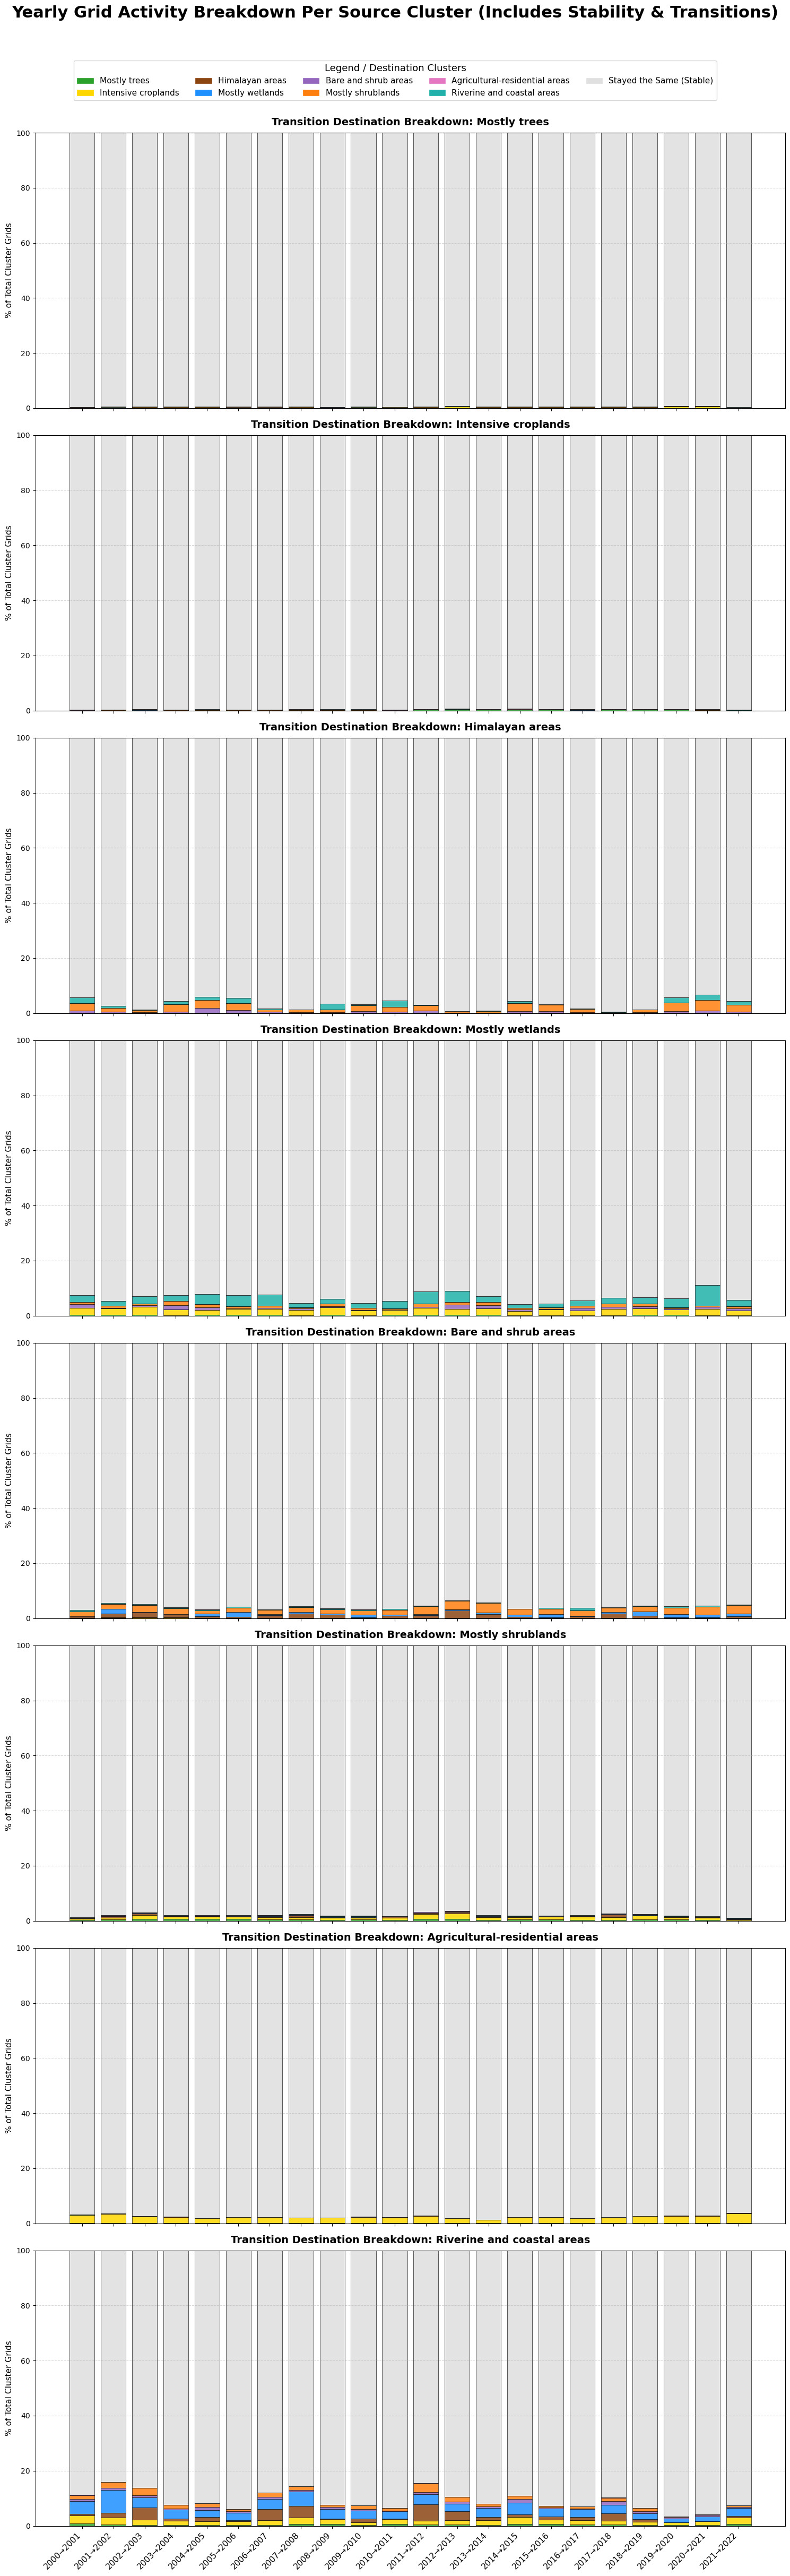

In [59]:
plot_transitions_per_cluster_percentage(wide_data_final, n_clusters=8)

## Cosine similarity stability checks

In [60]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches

In [61]:
YEARS = range(2000, 2023) 
CSV_DIR = "./spatial_clusters_cosine_similarity" 
FILE_PATTERN = "spatial_{year}.csv"
ID_COL = "s2_id"
CLUSTER_COL = "cluster"
STABILITY_THRESHOLD = 80.0

In [62]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_transitions_per_cluster_percentage(wide_df, n_clusters):
    """Plots transition distribution tracks per cluster using a stacked bar method."""

    cluster_names = {
        0: "Mostly trees",
        1: "Intensive croplands",
        2: "Mostly shrublands",
        3: "Himalayan areas",
        4: "Mostly wetland",
        5: "Riverine and coastal areas",
        6: "Agricultural and residential areas",
        7: "Crops and trees",
        8: "Bare and shrub areas",
        9: "Crops and shrub areas",
        10: "Trees and shrub areas",
    }

    year_cols = [str(y) for y in YEARS if str(y) in wide_df.columns]
    labels = []

    for i in range(len(year_cols) - 1):
        labels.append(f"{year_cols[i]}→{year_cols[i+1]}")

    columns_with_stayed = list(range(n_clusters)) + ["Stayed Same"]
    source_dfs = {
        src: pd.DataFrame(0.0, index=labels, columns=columns_with_stayed)
        # Fix: Ensure range is dynamic to your actual number of clusters
        for src in range(n_clusters)
    }

    # Populate transition metrics
    for i in range(len(year_cols) - 1):
        y1, y2 = year_cols[i], year_cols[i + 1]
        label = f"{y1}→{y2}"

        both = wide_df[[y1, y2]].replace(-1, np.nan).dropna()

        for src in range(n_clusters):
            starts_in_src = both[both[y1] == src]
            total_in_cluster = len(starts_in_src)

            if total_in_cluster > 0:
                # Calculate stable grids
                num_stayed = (starts_in_src[y1] == starts_in_src[y2]).sum()
                source_dfs[src].at[label, "Stayed Same"] = (
                    num_stayed / total_in_cluster
                ) * 100

                # Calculate destination shifts
                changed_grids = starts_in_src[
                    starts_in_src[y1] != starts_in_src[y2]
                ]
                if len(changed_grids) > 0:
                    counts = changed_grids[y2].value_counts()
                    for dest in range(n_clusters):
                        if dest in counts.index:
                            pct = (counts[dest] / total_in_cluster) * 100
                            source_dfs[src].at[label, dest] = pct

    fig, axes = plt.subplots(
        nrows=n_clusters,
        ncols=1,
        figsize=(15, 6 * n_clusters),
        sharex=True,
    )

    # --- COLOR FIX HERE ---
    # tab20 safely gives us 20 unique colors so clusters 9 and 10 won't overlap anymore
    colors = plt.cm.tab20(np.linspace(0, 1, n_clusters))

    for src in range(n_clusters):
        ax = axes[src]
        df = source_dfs[src]
        descriptive_name = cluster_names.get(src, f"Cluster {src}")

        bottom_bars = np.zeros(len(df))

        # Plot structural transitions first
        for dest in range(n_clusters):
            if src == dest:
                continue

            ax.bar(
                df.index,
                df[dest],
                bottom=bottom_bars,
                color=colors[dest],
                edgecolor="black",
                linewidth=0.5,
                alpha=0.85,
            )
            bottom_bars += df[dest]

        # Stack stability component on top
        ax.bar(
            df.index,
            df["Stayed Same"],
            bottom=bottom_bars,
            color="#E0E0E0",
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
        )

        ax.set_title(
            f"Transition Destination Breakdown: {descriptive_name}",
            fontsize=14,
            fontweight="bold",
            pad=10,
        )
        ax.set_ylabel("% of Total Cluster Grids", fontsize=11)
        ax.set_ylim(0, 100)
        ax.grid(axis="y", linestyle="--", alpha=0.5)

    # Use actual set_xticks to prevent warning logs in newer matplotlib versions
    axes[-1].set_xticks(range(len(labels)))
    axes[-1].set_xticklabels(labels, rotation=45, ha="right", fontsize=11)

    legend_handles = []
    for c_id in range(n_clusters):
        legend_handles.append(
            mpatches.Patch(
                color=colors[c_id],
                alpha=0.85,
                label=cluster_names.get(c_id, f"Cluster {c_id}"),
            )
        )
    # Add the final stable category handle
    legend_handles.append(
        mpatches.Patch(
            color="#E0E0E0", alpha=0.9, label="Stayed the Same (Stable)"
        )
    )

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.99),
        ncol=4,  # Reduced slightly so text layout doesn't overlap long labels
        fontsize=11,
        title="Legend / Destination Clusters",
        title_fontsize=13,
    )

    plt.suptitle(
        "Yearly Grid Activity Breakdown Per Source Cluster (Cosine Similarity)",
        fontsize=22,
        y=1.01,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)  # Given more space for the legend room
    plt.savefig("spatial_cluster_stacked_transitions_cosine.png", dpi=150)
    plt.show()

In [23]:
wide_cluster_df = load_spatial_data()

print("\n--- Wide DataFrame Sample ---")
print(wide_cluster_df.head())
print(f"Total Unique Grids Loaded: {len(wide_cluster_df)}")

Loading 2000...
Loading 2001...
Loading 2002...
Loading 2003...
Loading 2004...
Loading 2005...
Loading 2006...
Loading 2007...
Loading 2008...
Loading 2009...
Loading 2010...
Loading 2011...
Loading 2012...
Loading 2013...
Loading 2014...
Loading 2015...
Loading 2016...
Loading 2017...
Loading 2018...
Loading 2019...
Loading 2020...
Loading 2021...
Loading 2022...

--- Wide DataFrame Sample ---
                        2000  2001  2002  2003  2004  2005  2006  2007  2008  \
s2_id                                                                          
id_3983268685966999552     0     0     0     0     0     0     0     0     0   
id_3499096541652582400     4     4     4     4     4     4     4     4     4   
id_4187064815442722816     5     5     5     4     4     4     4     4     4   
id_4304991526330564608     5     5     5     5     5     5     5     5     5   
id_4187066155472519168     5     5     5     5     5     5     5     5     5   

                        2009  ...  2013 

In [25]:
stability_metrics_df = compute_stability_metrics(wide_cluster_df)

print("\n--- Stability Metrics Summary ---")
print(stability_metrics_df.head())

stability_metrics_df.to_csv("grid_stability_metrics_cosine.csv")

Computing stability metrics...

--- Stability Metrics Summary ---
                        mode_cluster  mode_freq  stability_pct  n_unique  \
s2_id                                                                      
id_3983268685966999552             0         23          100.0         1   
id_3499096541652582400             4         23          100.0         1   
id_4187064815442722816             4         20           87.0         2   
id_4304991526330564608             5         23          100.0         1   
id_4187066155472519168             5         23          100.0         1   

                        is_stable  valid_years  
s2_id                                           
id_3983268685966999552       True           23  
id_3499096541652582400       True           23  
id_4187064815442722816       True           23  
id_4304991526330564608       True           23  
id_4187066155472519168       True           23  



Generating Stability Distribution Plot...


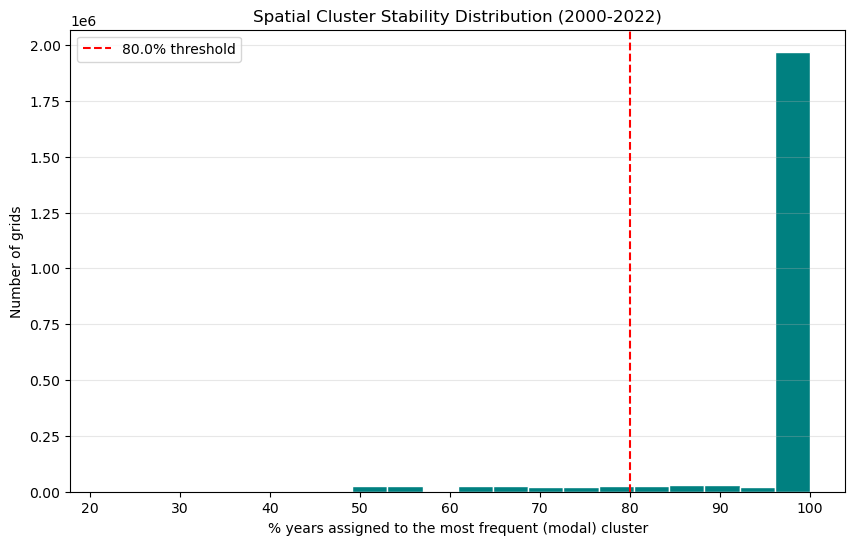

In [26]:
print("\nGenerating Stability Distribution Plot...")
plot_stability_results(stability_metrics_df)

Generating Year-over-Year Net Transition Rates...


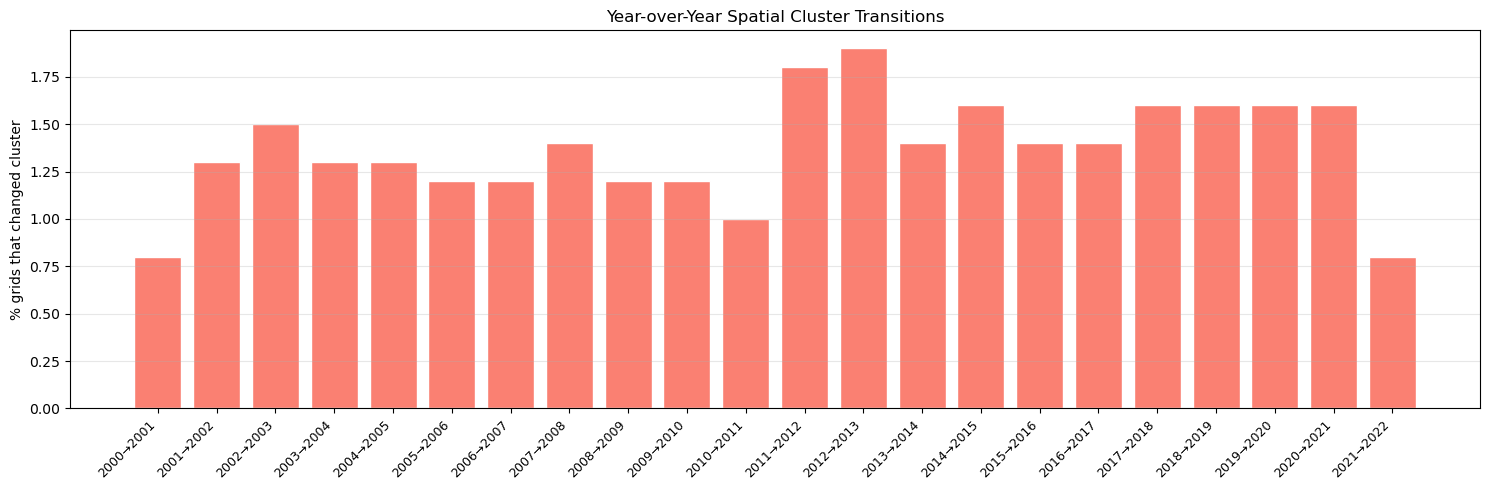

In [27]:
print("Generating Year-over-Year Net Transition Rates...")
plot_transitions(wide_cluster_df)

Generating Stacked Multi-Row Cluster Activity Charts...


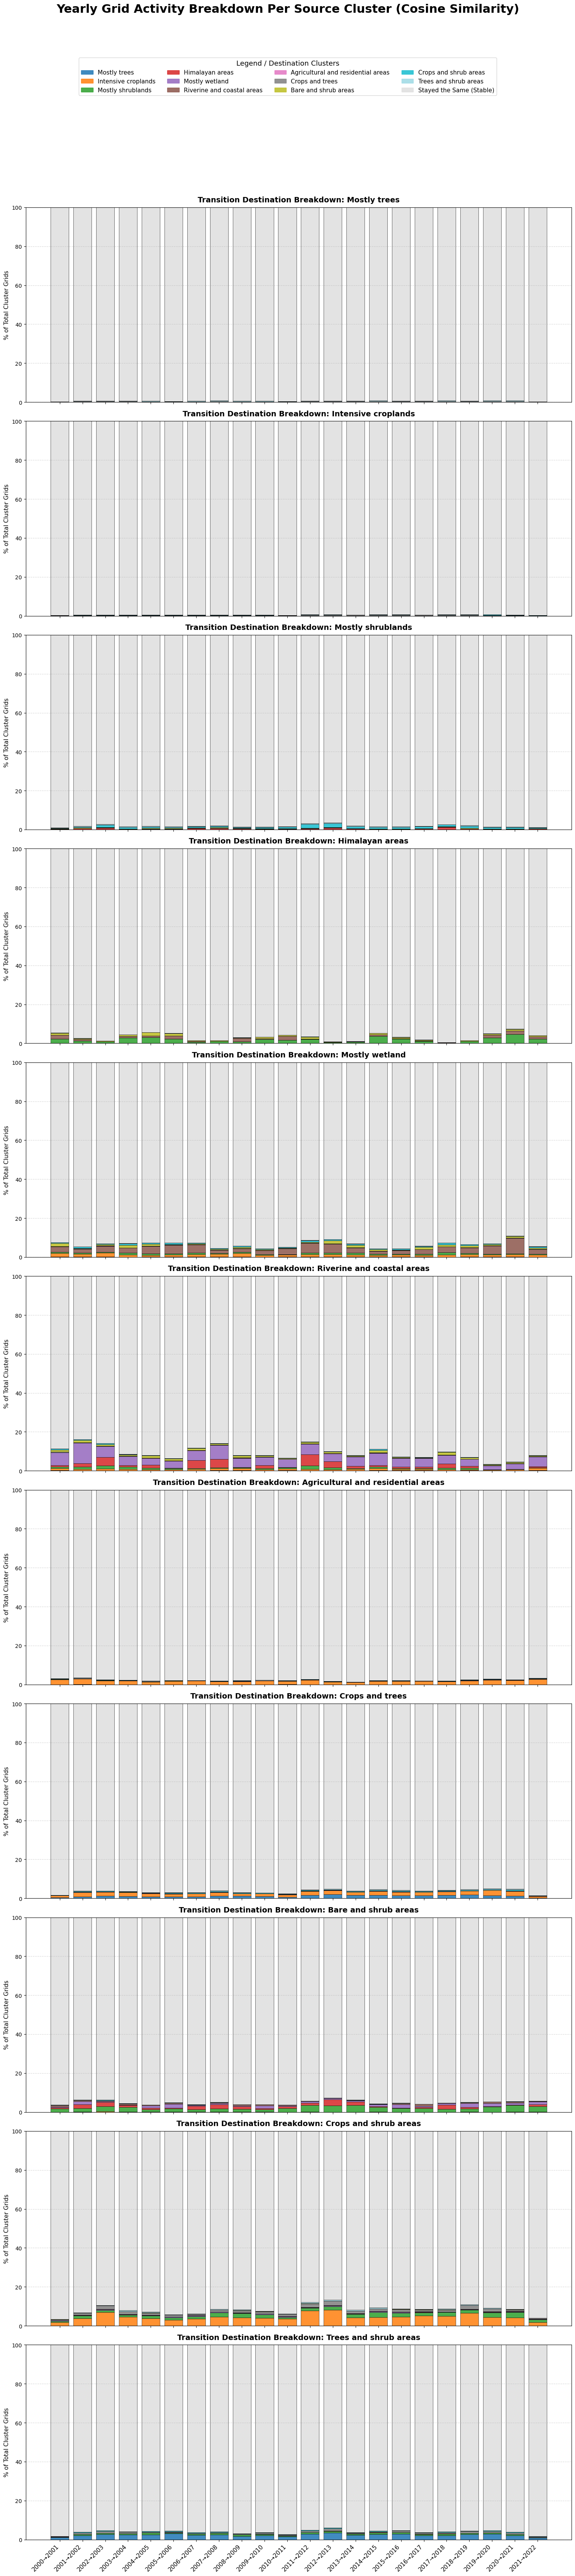

In [63]:
print("Generating Stacked Multi-Row Cluster Activity Charts...")
plot_transitions_per_cluster_percentage(wide_cluster_df, n_clusters=11)

## Merge 'Mostly wetlands' and 'Riverine & coastal areas'

In [64]:
import os
import pandas as pd

input_folder = "spatial_clusters_cosine_similarity"
output_folder = "spatial_clusters_cosine_similarity_fixed"

os.makedirs(output_folder, exist_ok=True)

for year in range(2000, 2023):
    input_file = os.path.join(input_folder, f"spatial_{year}.csv")
    output_file = os.path.join(output_folder, f"spatial_{year}.csv")
    
    if not os.path.exists(input_file):
        print(f"Skipping: {input_file} not found.")
        continue
        
    df = pd.read_csv(input_file)
    
    df['cluster'] = df['cluster'].apply(lambda x: x - 1 if 5 <= x <= 11 else x)
    
    df.to_csv(output_file, index=False)
    print(f"Processed and saved: {output_file}")

Processed and saved: spatial_clusters_cosine_similarity_fixed\spatial_2000.csv
Processed and saved: spatial_clusters_cosine_similarity_fixed\spatial_2001.csv
Processed and saved: spatial_clusters_cosine_similarity_fixed\spatial_2002.csv
Processed and saved: spatial_clusters_cosine_similarity_fixed\spatial_2003.csv
Processed and saved: spatial_clusters_cosine_similarity_fixed\spatial_2004.csv
Processed and saved: spatial_clusters_cosine_similarity_fixed\spatial_2005.csv
Processed and saved: spatial_clusters_cosine_similarity_fixed\spatial_2006.csv
Processed and saved: spatial_clusters_cosine_similarity_fixed\spatial_2007.csv
Processed and saved: spatial_clusters_cosine_similarity_fixed\spatial_2008.csv
Processed and saved: spatial_clusters_cosine_similarity_fixed\spatial_2009.csv
Processed and saved: spatial_clusters_cosine_similarity_fixed\spatial_2010.csv
Processed and saved: spatial_clusters_cosine_similarity_fixed\spatial_2011.csv
Processed and saved: spatial_clusters_cosine_similar

In [65]:
YEARS = range(2000, 2023) 
CSV_DIR = "./spatial_clusters_cosine_similarity_fixed" 
FILE_PATTERN = "spatial_{year}.csv"
ID_COL = "s2_id"
CLUSTER_COL = "cluster"
STABILITY_THRESHOLD = 80.0

In [66]:
wide_cluster_cosine_fixed_df = load_spatial_data()

print("\n--- Wide DataFrame Sample ---")
print(wide_cluster_cosine_fixed_df.head())
print(f"Total Unique Grids Loaded: {len(wide_cluster_cosine_fixed_df)}")

Loading 2000...
Loading 2001...
Loading 2002...
Loading 2003...
Loading 2004...
Loading 2005...
Loading 2006...
Loading 2007...
Loading 2008...
Loading 2009...
Loading 2010...
Loading 2011...
Loading 2012...
Loading 2013...
Loading 2014...
Loading 2015...
Loading 2016...
Loading 2017...
Loading 2018...
Loading 2019...
Loading 2020...
Loading 2021...
Loading 2022...

--- Wide DataFrame Sample ---
                        2000  2001  2002  2003  2004  2005  2006  2007  2008  \
s2_id                                                                          
id_3983268685966999552     0     0     0     0     0     0     0     0     0   
id_3499096541652582400     4     4     4     4     4     4     4     4     4   
id_4187064815442722816     4     4     4     4     4     4     4     4     4   
id_4304991526330564608     4     4     4     4     4     4     4     4     4   
id_4187066155472519168     4     4     4     4     4     4     4     4     4   

                        2009  ...  2013 

In [67]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_transitions_per_cluster_percentage_fixed(wide_df, n_clusters):
    """Plots transition distribution tracks per cluster using a stacked bar method."""

    cluster_names = {
        0: "Mostly trees",
        1: "Intensive croplands",
        2: "Mostly shrublands",
        3: "Himalayan areas",
        4: "Mostly wetland, Riverine and coastal areas",
        5: "Agricultural and residential areas",
        6: "Crops and trees",
        7: "Bare and shrub areas",
        8: "Crops and shrub areas",
        9: "Trees and shrub areas",
    }

    year_cols = [str(y) for y in YEARS if str(y) in wide_df.columns]
    labels = []

    for i in range(len(year_cols) - 1):
        labels.append(f"{year_cols[i]}→{year_cols[i+1]}")

    columns_with_stayed = list(range(n_clusters)) + ["Stayed Same"]
    source_dfs = {
        src: pd.DataFrame(0.0, index=labels, columns=columns_with_stayed)
        # Fix: Ensure range is dynamic to your actual number of clusters
        for src in range(n_clusters)
    }

    # Populate transition metrics
    for i in range(len(year_cols) - 1):
        y1, y2 = year_cols[i], year_cols[i + 1]
        label = f"{y1}→{y2}"

        both = wide_df[[y1, y2]].replace(-1, np.nan).dropna()

        for src in range(n_clusters):
            starts_in_src = both[both[y1] == src]
            total_in_cluster = len(starts_in_src)

            if total_in_cluster > 0:
                # Calculate stable grids
                num_stayed = (starts_in_src[y1] == starts_in_src[y2]).sum()
                source_dfs[src].at[label, "Stayed Same"] = (
                    num_stayed / total_in_cluster
                ) * 100

                # Calculate destination shifts
                changed_grids = starts_in_src[
                    starts_in_src[y1] != starts_in_src[y2]
                ]
                if len(changed_grids) > 0:
                    counts = changed_grids[y2].value_counts()
                    for dest in range(n_clusters):
                        if dest in counts.index:
                            pct = (counts[dest] / total_in_cluster) * 100
                            source_dfs[src].at[label, dest] = pct

    fig, axes = plt.subplots(
        nrows=n_clusters,
        ncols=1,
        figsize=(15, 6 * n_clusters),
        sharex=True,
    )

    # --- COLOR FIX HERE ---
    # tab20 safely gives us 20 unique colors so clusters 9 and 10 won't overlap anymore
    colors = plt.cm.tab20(np.linspace(0, 1, n_clusters))

    for src in range(n_clusters):
        ax = axes[src]
        df = source_dfs[src]
        descriptive_name = cluster_names.get(src, f"Cluster {src}")

        bottom_bars = np.zeros(len(df))

        # Plot structural transitions first
        for dest in range(n_clusters):
            if src == dest:
                continue

            ax.bar(
                df.index,
                df[dest],
                bottom=bottom_bars,
                color=colors[dest],
                edgecolor="black",
                linewidth=0.5,
                alpha=0.85,
            )
            bottom_bars += df[dest]

        # Stack stability component on top
        ax.bar(
            df.index,
            df["Stayed Same"],
            bottom=bottom_bars,
            color="#E0E0E0",
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
        )

        ax.set_title(
            f"Transition Destination Breakdown: {descriptive_name}",
            fontsize=14,
            fontweight="bold",
            pad=10,
        )
        ax.set_ylabel("% of Total Cluster Grids", fontsize=11)
        ax.set_ylim(0, 100)
        ax.grid(axis="y", linestyle="--", alpha=0.5)

    # Use actual set_xticks to prevent warning logs in newer matplotlib versions
    axes[-1].set_xticks(range(len(labels)))
    axes[-1].set_xticklabels(labels, rotation=45, ha="right", fontsize=11)

    legend_handles = []
    for c_id in range(n_clusters):
        legend_handles.append(
            mpatches.Patch(
                color=colors[c_id],
                alpha=0.85,
                label=cluster_names.get(c_id, f"Cluster {c_id}"),
            )
        )
    # Add the final stable category handle
    legend_handles.append(
        mpatches.Patch(
            color="#E0E0E0", alpha=0.9, label="Stayed the Same (Stable)"
        )
    )

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.99),
        ncol=4,  # Reduced slightly so text layout doesn't overlap long labels
        fontsize=11,
        title="Legend / Destination Clusters",
        title_fontsize=13,
    )

    plt.suptitle(
        "Yearly Grid Activity Breakdown Per Source Cluster (Cosine Similarity)",
        fontsize=22,
        y=1.01,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)  # Given more space for the legend room
    plt.savefig("spatial_cluster_stacked_transitions_cosine.png", dpi=150)
    plt.show()

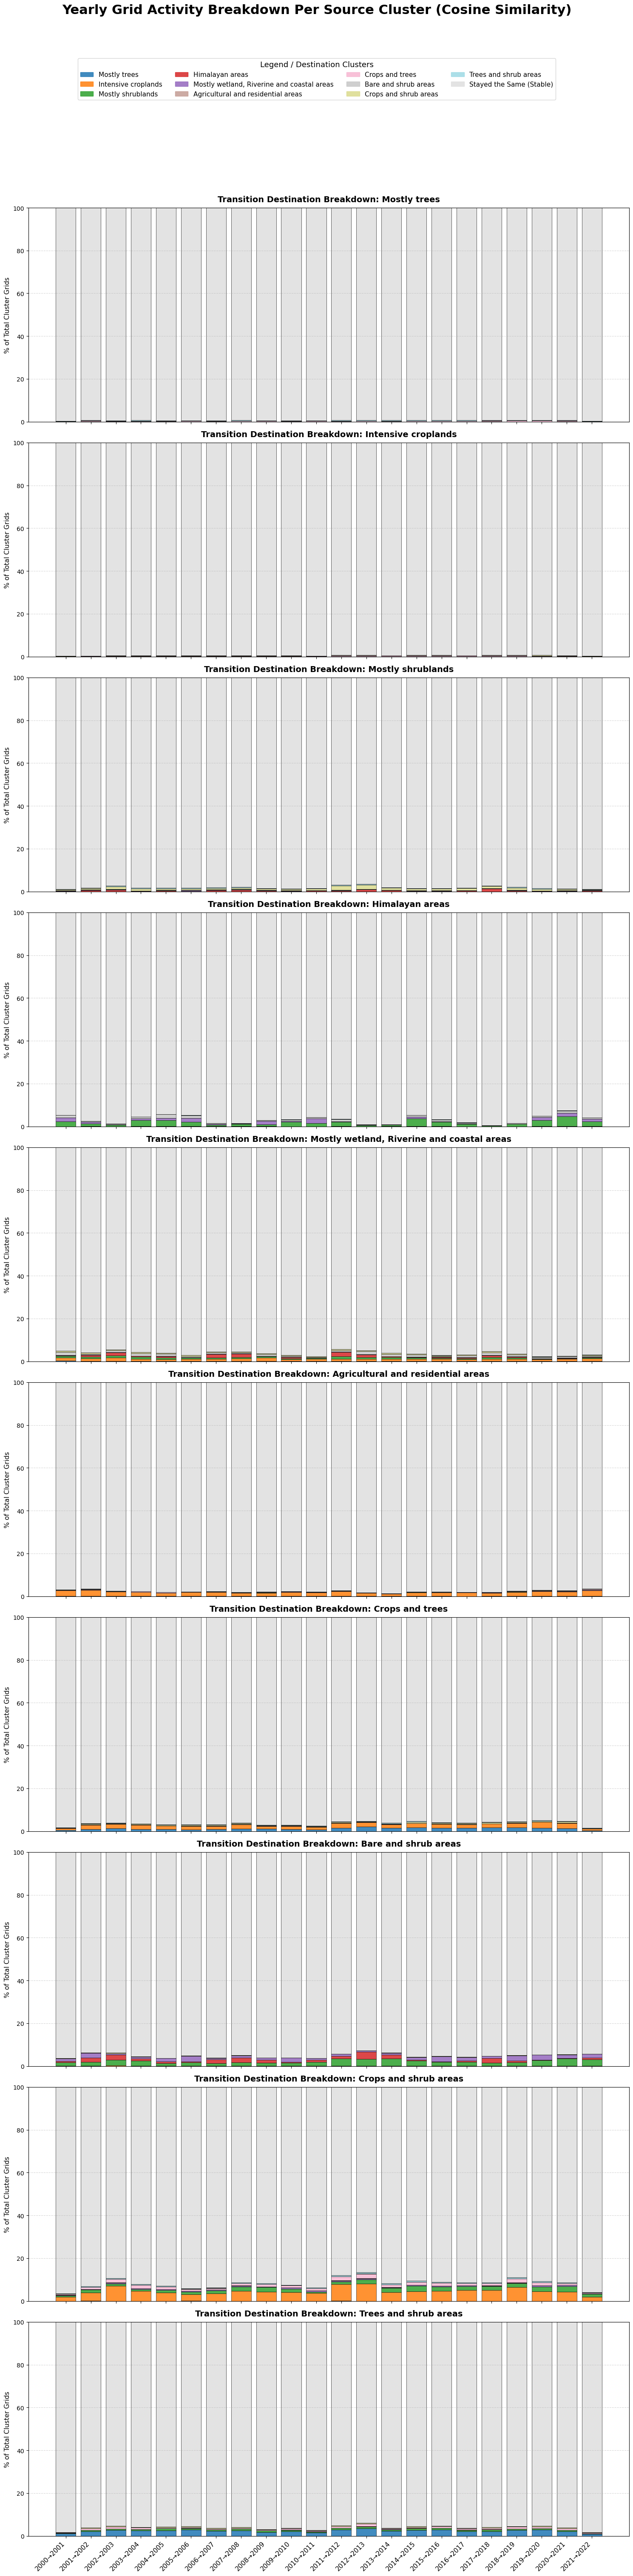

In [68]:
plot_transitions_per_cluster_percentage_fixed(wide_cluster_cosine_fixed_df, n_clusters=10)